In [9]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/fake-review-detector/data/raw', exist_ok=True)
os.makedirs('/content/drive/MyDrive/fake-review-detector/data/processed', exist_ok=True)
os.makedirs('/content/drive/MyDrive/fake-review-detector/models', exist_ok=True)
os.makedirs('/content/drive/MyDrive/fake-review-detector/outputs', exist_ok=True)

print("✅ Google Drive ready!")n

Mounted at /content/drive
✅ Google Drive ready!


In [10]:
import os
import json

# Replace YOUR_USERNAME and YOUR_NEW_TOKEN with your actual values
# (after you regenerate the token)
kaggle_creds = {
    "username": "lakshyakanjani",
    "key": "KGAT_7b51696cf378c07219569309ef4ce162"
}

# Create the kaggle.json file manually
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_creds, f)

!chmod 600 ~/.kaggle/kaggle.json
print("✅ kaggle.json created successfully")

✅ kaggle.json created successfully


In [11]:
# Download the dataset
!kaggle datasets download -d rtatman/deceptive-opinion-spam-corpus -p data/raw/
!unzip -q data/raw/deceptive-opinion-spam-corpus.zip -d data/raw/deceptive-corpus

print("✅ Downloaded!")

# Verify structure
import os
for root, dirs, files_list in os.walk("data/raw/deceptive-corpus"):
    print(root)

Dataset URL: https://www.kaggle.com/datasets/rtatman/deceptive-opinion-spam-corpus
License(s): CC-BY-NC-SA-4.0
deceptive-opinion-spam-corpus.zip: Skipping, found more recently modified local copy (use --force to force download)
replace data/raw/deceptive-corpus/deceptive-opinion.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
✅ Downloaded!
data/raw/deceptive-corpus


In [12]:
import os

# See everything inside
for root, dirs, files_list in os.walk("data/raw/deceptive-corpus"):
    print(f"\n📁 {root}")
    for f in files_list[:5]:  # show first 5 files in each folder
        print(f"   📄 {f}")


📁 data/raw/deceptive-corpus
   📄 deceptive-opinion.csv


In [13]:
import pandas as pd

# Load directly from CSV
df = pd.read_csv("data/raw/deceptive-corpus/deceptive-opinion.csv")

# Check what columns we have
print("📊 Columns:", df.columns.tolist())
print(f"📝 Shape: {df.shape}")
print("\n🔍 First 3 rows:")
df.head(3)

📊 Columns: ['deceptive', 'hotel', 'polarity', 'source', 'text']
📝 Shape: (1600, 5)

🔍 First 3 rows:


,deceptive,hotel,polarity,source,text
0,truthful,conrad,positive,TripAdvisor,We stayed for a one night getaway with family ...
1,truthful,hyatt,positive,TripAdvisor,Triple A rate with upgrade to view room was le...
2,truthful,hyatt,positive,TripAdvisor,This comes a little late as I'm finally catchi...


In [14]:
from textblob import TextBlob
import re

# Step 1 — Clean and map labels
df = df.rename(columns={'text': 'review_text'})
df['label'] = df['deceptive'].map({'deceptive': 1, 'truthful': 0})

print("✅ Label distribution:")
print(df['label'].value_counts())
print(f"\n📊 Fake: {df['label'].sum()} | Real: {(df['label']==0).sum()}")

# Step 2 — Engineer features
def engineer_features(df):
    df['review_length']           = df['review_text'].apply(len)
    df['word_count']              = df['review_text'].apply(lambda x: len(x.split()))
    df['avg_word_length']         = df['review_text'].apply(
                                        lambda x: sum(len(w) for w in x.split()) / (len(x.split()) + 1))
    df['exclamation_count']       = df['review_text'].apply(lambda x: x.count('!'))
    df['question_count']          = df['review_text'].apply(lambda x: x.count('?'))
    df['capital_ratio']           = df['review_text'].apply(
                                        lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
    df['sentiment_polarity']      = df['review_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
    df['sentiment_subjectivity']  = df['review_text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
    df['first_person_count']      = df['review_text'].apply(
                                        lambda x: len(re.findall(r'\b(I|me|my|myself|mine)\b', x, re.I)))
    return df

print("\n⏳ Engineering features (takes ~30 seconds)...")
df = engineer_features(df)
print("✅ Features engineered!")
print(df[['review_text','label','sentiment_polarity','first_person_count']].head(3))

✅ Label distribution:
label
0    800
1    800
Name: count, dtype: int64

📊 Fake: 800 | Real: 800

⏳ Engineering features (takes ~30 seconds)...
✅ Features engineered!
                                         review_text  label  \
0  We stayed for a one night getaway with family ...      0   
1  Triple A rate with upgrade to view room was le...      0   
2  This comes a little late as I'm finally catchi...      0   

   sentiment_polarity  first_person_count  
0            0.276167                   1  
1            0.321687                   0  
2            0.194881                   5  


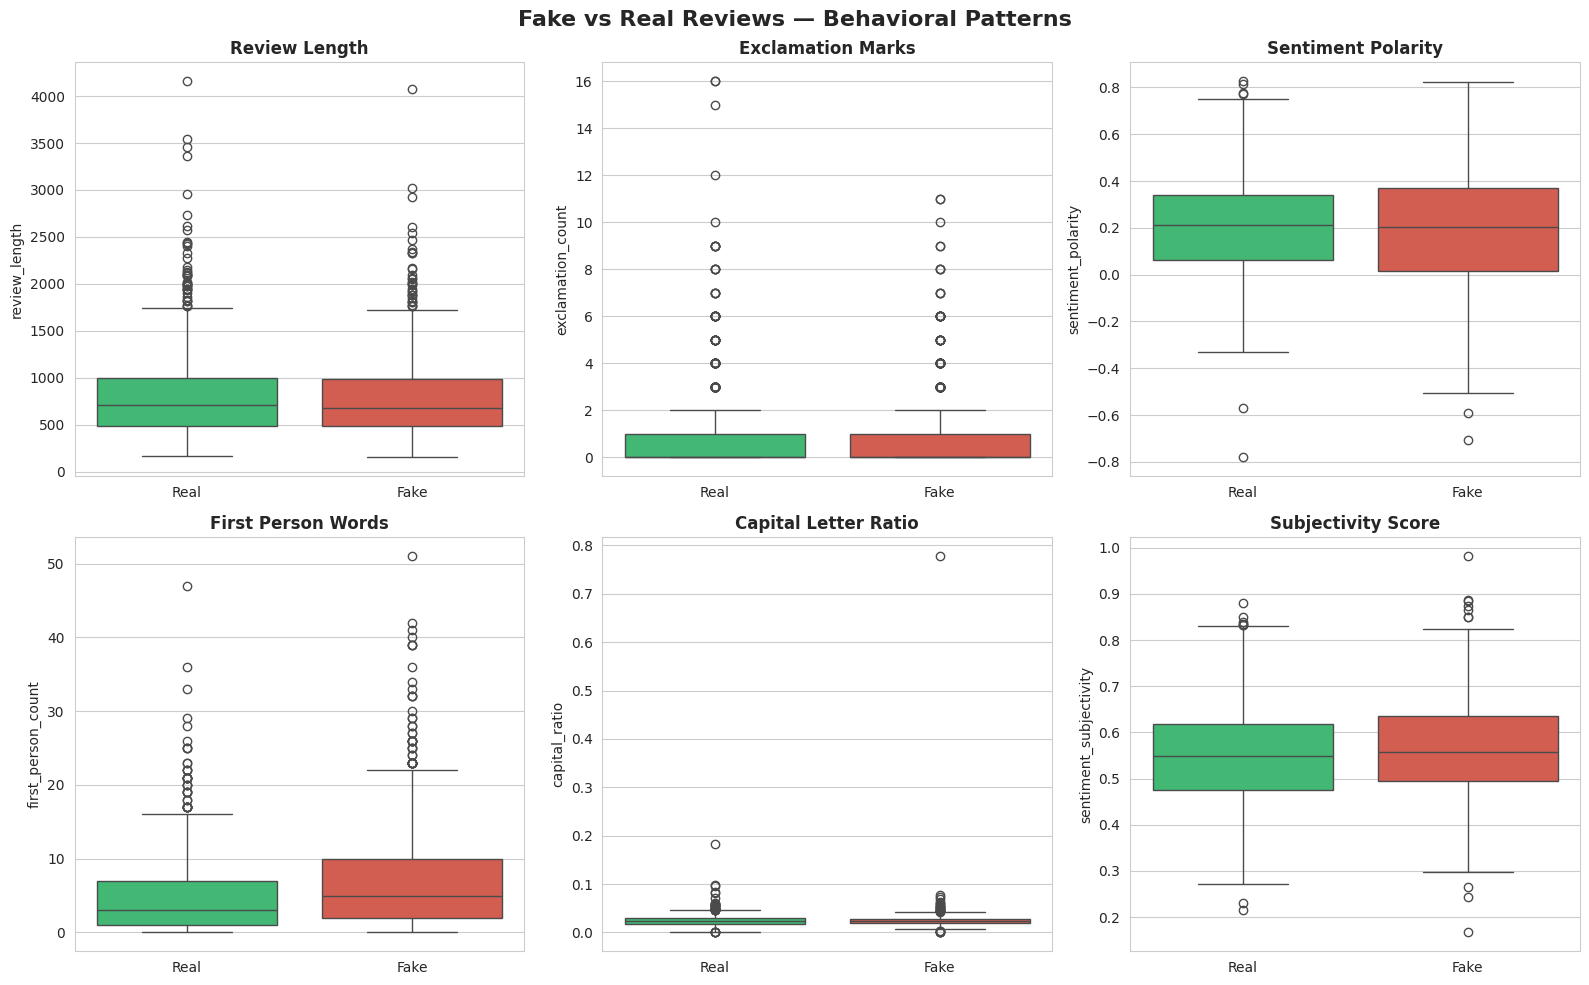

✅ EDA chart saved!


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Fake vs Real Reviews — Behavioral Patterns", fontsize=16, fontweight='bold')

features = [
    ('review_length',           'Review Length'),
    ('exclamation_count',       'Exclamation Marks'),
    ('sentiment_polarity',      'Sentiment Polarity'),
    ('first_person_count',      'First Person Words'),
    ('capital_ratio',           'Capital Letter Ratio'),
    ('sentiment_subjectivity',  'Subjectivity Score'),
]

# Create a string label column just for plotting
df['label_str'] = df['label'].map({0: 'Real', 1: 'Fake'})

for ax, (feat, title) in zip(axes.flatten(), features):
    sns.boxplot(
        data=df, x='label_str', y=feat, ax=ax,
        hue='label_str',                           # ← fix for new seaborn
        palette={'Real': '#2ecc71', 'Fake': '#e74c3c'},
        order=['Real', 'Fake'],
        legend=False
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig("outputs/eda_patterns.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA chart saved!")

In [16]:

df.to_csv("/content/drive/MyDrive/fake-review-detector/data/processed/reviews_with_features.csv", index=False)
print("✅ Saved permanently to Google Drive!")

✅ Saved permanently to Google Drive!
